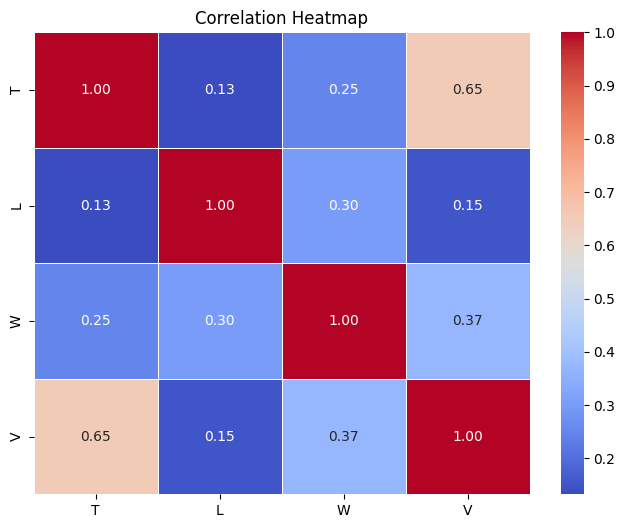

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Function to read and concatenate CSV files from a directory
def load_data_from_folder(folder_path):
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    data_list = [pd.read_csv(os.path.join(folder_path, file)) for file in csv_files]
    combined_data = pd.concat(data_list, ignore_index=True)
    return combined_data

# Function to normalize features and target
def normalize_data(X, y):
    # Initialize MinMaxScaler for input features and target
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    # Normalize input features (T, L, W)
    X_scaled = scaler_X.fit_transform(X)
    
    # Normalize the target variable (V)
    y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # Reshape y for the scaler
    
    return X_scaled, y_scaled

# Function to plot correlation heatmap
def plot_correlation_heatmap(data):
    plt.figure(figsize=(8, 6))
    corr = data.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Heatmap')
    plt.show()

# Main execution flow
if __name__ == "__main__":
    training_folder_path = r'C:\Users\ACER\Desktop\as\Training'  # Update with your training folder path
    
    # Load the training data
    train_data = load_data_from_folder(training_folder_path)

    # Define input features (T, L, W) and target variable (V) for training data
    X_train = train_data[['T', 'L', 'W']]
    y_train = train_data['V']
    
    # Normalize the input features and target for training
    X_train_scaled, y_train_scaled = normalize_data(X_train, y_train)
    
    # Create a DataFrame for normalized data to plot the correlation heatmap
    normalized_train_data = pd.DataFrame(np.hstack((X_train_scaled, y_train_scaled)), columns=['T', 'L', 'W', 'V'])
    
    # Plot correlation heatmap for normalized data
    plot_correlation_heatmap(normalized_train_data)
